# Task 5：通用股票机器学习研究 Notebook

本 Notebook 是一个可复用模板：导入任意单只或多只股票的日线 CSV、CSV 目录或 `pandas.DataFrame`，只修改配置即可选择股票、预测任务和算法。

默认实验使用项目股票数据，按时间划分为：2018–2022 训练、2023–2024 验证、2025–最近交易日测试。所有滚动特征只使用当时已知数据；最终测试集不参与特征、参数或阈值选择。

> 研究用途，不构成投资建议。

## 1. 环境、随机种子与配置

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import yaml

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    roc_curve, roc_auc_score)
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
# 自动选择本机中文字体，解决标题、坐标轴和图例显示方块的问题。
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for chinese_font in ['Hiragino Sans GB', 'Heiti SC', 'Arial Unicode MS', 'STSong', 'SimHei']:
    if chinese_font in available_fonts:
        plt.rcParams['font.sans-serif'] = [chinese_font, 'DejaVu Sans']
        break
plt.rcParams['axes.unicode_minus'] = False
print('图表字体:', plt.rcParams['font.sans-serif'][0])

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'task5_machine_learning').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
CONFIG_PATH = PROJECT_ROOT / 'task5_machine_learning' / 'config.yaml'
with CONFIG_PATH.open(encoding='utf-8') as f:
    CONFIG = yaml.safe_load(f)
CONFIG

图表字体: Hiragino Sans GB


{'data': {'source': 'data/processed/equities/daily/ml_equities_daily_20180101_20260712.csv',
  'input_format': 'auto',
  'column_mapping': None,
  'selected_symbols': 'all',
  'price_adjustment': 'qfq'},
 'experiment': {'task_type': 'both',
  'selected_models': 'all',
  'per_symbol': True},
 'target': {'forecast_horizon': 1,
  'regression_target': 'future_return',
  'classification_threshold': 0.0},
 'features': {'return_windows': [1, 5, 10, 20],
  'sma_windows': [5, 10, 20, 60],
  'volatility_windows': [10, 20],
  'rsi_window': 14,
  'atr_window': 14,
  'volume_window': 20,
  'include_calendar': False},
 'split': {'mode': 'fixed_years',
  'train_start': '2018-01-01',
  'train_end': '2022-12-31',
  'validation_start': '2023-01-01',
  'validation_end': '2024-12-31',
  'test_start': '2025-01-01',
  'test_end': None,
  'internal_train_ratio': 0.7,
  'time_series_cv_splits': 5},
 'models': {'random_state': 42,
  'linear_regression': {},
  'logistic_regression': {'max_iter': 1000},
  'decis

## 2. 通用数据入口与字段映射

最低字段为日期和 OHLC；多股票文件还需要证券标识。函数支持一个 CSV、CSV 目录或 DataFrame。项目的 `qfq_*` 字段会自动优先映射为分析用 OHLC，避免误用未复权价格。

In [2]:
ALIASES = {
    'date': ['date', 'trade_date', 'datetime', '日期'],
    'symbol': ['symbol', 'ts_code', 'ticker', 'code', '证券代码'],
    'open': ['qfq_open', 'adj_open', 'open', '开盘'],
    'high': ['qfq_high', 'adj_high', 'high', '最高'],
    'low': ['qfq_low', 'adj_low', 'low', '最低'],
    'close': ['qfq_close', 'adj_close', 'close', '收盘'],
    'pre_close': ['qfq_pre_close', 'adj_pre_close', 'pre_close', '昨收'],
    'volume': ['vol', 'volume', '成交量'],
    'amount': ['amount', '成交额'],
}

def _read_source(source):
    if isinstance(source, pd.DataFrame):
        return source.copy()
    source = Path(source)
    if source.is_dir():
        files = sorted(source.glob('*.csv'))
        if not files:
            raise FileNotFoundError(f'目录中没有 CSV: {source}')
        frames = []
        for f in files:
            part = pd.read_csv(f)
            part['_source_file'] = f.name
            frames.append(part)
        return pd.concat(frames, ignore_index=True)
    return pd.read_csv(source)

def load_stock_data(source, input_format='auto', column_mapping=None, selected_symbols=None):
    raw = _read_source(source)
    mapping = dict(column_mapping or {})
    for standard, candidates in ALIASES.items():
        if standard in mapping:
            continue
        found = next((c for c in candidates if c in raw.columns), None)
        if found:
            mapping[standard] = found
    required = ['date', 'open', 'high', 'low', 'close']
    missing = [c for c in required if c not in mapping]
    if missing:
        raise ValueError(f'缺少必要字段映射: {missing}; 当前列: {list(raw.columns)}')
    # Build a fresh standardized frame so raw and qfq columns cannot create duplicate names.
    df = pd.DataFrame({standard: raw[source_col] for standard, source_col in mapping.items()})
    if 'symbol' not in df:
        df['symbol'] = 'SINGLE_STOCK'
    df['date'] = pd.to_datetime(df['date'].astype(str), errors='coerce')
    for c in ['open','high','low','close','pre_close','volume','amount']:
        if c in df: df[c] = pd.to_numeric(df[c], errors='coerce')
    if 'pre_close' not in df:
        df['pre_close'] = df.groupby('symbol')['close'].shift(1)
    if 'volume' not in df:
        df['volume'] = np.nan
    keep = ['date','symbol','open','high','low','close','pre_close','volume']
    if 'amount' in df: keep.append('amount')
    df = df[keep].dropna(subset=['date','open','high','low','close'])
    df = df.drop_duplicates(['symbol','date']).sort_values(['symbol','date']).reset_index(drop=True)
    if selected_symbols not in (None, 'all'):
        wanted = [selected_symbols] if isinstance(selected_symbols, str) else selected_symbols
        df = df[df['symbol'].isin(wanted)].copy()
    if df.empty: raise ValueError('字段映射或证券筛选后没有数据')
    return df

source = PROJECT_ROOT / CONFIG['data']['source']
data = load_stock_data(source, CONFIG['data'].get('input_format','auto'),
                       CONFIG['data'].get('column_mapping'), CONFIG['data'].get('selected_symbols'))
print(f'行数: {len(data):,}; 股票数: {data.symbol.nunique()}')
display(data.groupby('symbol').agg(起始日期=('date','min'),结束日期=('date','max'),交易日数=('date','size')))
data.head()

行数: 5,633; 股票数: 3


,起始日期,结束日期,交易日数
symbol,,,
00981.HK,2018-01-02,2026-07-10,2094
01211.HK,2018-01-02,2026-07-10,2094
688981.SH,2020-07-16,2026-07-10,1445


,date,symbol,open,high,low,close,pre_close,volume,amount
0,2018-01-02,00981.HK,13.50,13.70,12.54,12.62,12.62,117161315.0,NaN
1,2018-01-03,00981.HK,12.72,12.90,12.46,12.52,12.62,68835533.0,NaN
2,2018-01-04,00981.HK,12.68,13.22,12.68,12.76,12.52,73912266.0,NaN
3,2018-01-05,00981.HK,12.72,13.08,12.28,12.46,12.76,55722714.0,NaN
4,2018-01-08,00981.HK,12.40,12.48,12.18,12.36,12.46,35346121.0,NaN


## 3. 数据质量与覆盖范围

,symbol,start,end,rows,duplicates,missing_ohlc,bad_high_low,negative_volume
0,00981.HK,2018-01-02,2026-07-10,2094,0,0,0,0
1,01211.HK,2018-01-02,2026-07-10,2094,0,0,0,0
2,688981.SH,2020-07-16,2026-07-10,1445,0,0,0,0


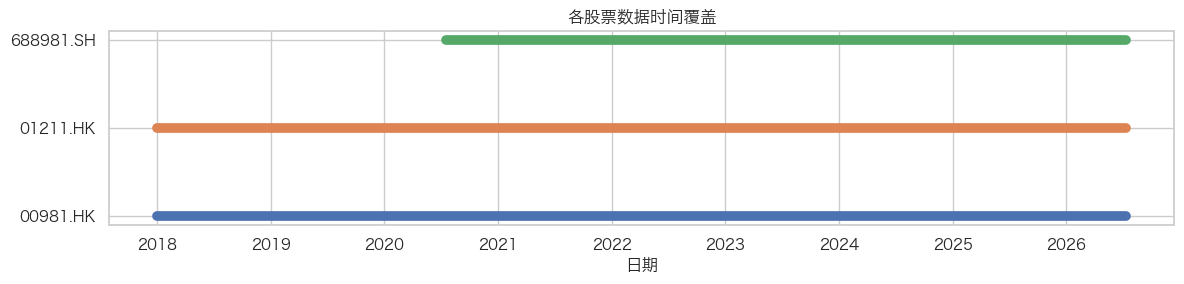

In [3]:
def validate_stock_data(df):
    rows=[]
    for symbol,g in df.groupby('symbol'):
        rows.append({
            'symbol':symbol, 'start':g.date.min(), 'end':g.date.max(), 'rows':len(g),
            'duplicates':g.duplicated('date').sum(),
            'missing_ohlc':int(g[['open','high','low','close']].isna().sum().sum()),
            'bad_high_low':int(((g.high < g[['open','close','low']].max(axis=1)) |
                                (g.low > g[['open','close','high']].min(axis=1))).sum()),
            'negative_volume':int((g.volume < 0).sum())
        })
    report=pd.DataFrame(rows)
    if (report[['duplicates','missing_ohlc','bad_high_low','negative_volume']].sum().sum()>0):
        raise ValueError('数据质量校验未通过，请查看 report')
    return report

data_report=validate_stock_data(data)
display(data_report)

fig,ax=plt.subplots(figsize=(12,max(3,0.6*len(data_report))))
for i,r in data_report.reset_index().iterrows():
    ax.plot([r.start,r.end],[i,i],linewidth=7)
ax.set_yticks(range(len(data_report))); ax.set_yticklabels(data_report.symbol)
ax.set_title('各股票数据时间覆盖'); ax.set_xlabel('日期')
plt.tight_layout(); plt.show()

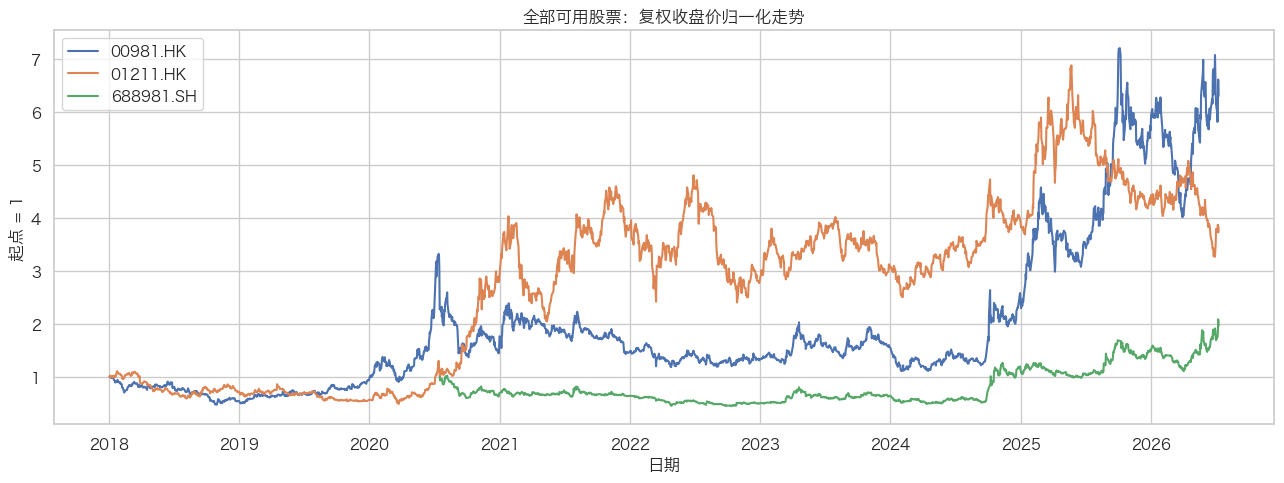

In [4]:
# 所有当前可用股票的复权收盘价（按各自起点归一化，便于跨币种比较）
plt.figure(figsize=(13,5))
for symbol,g in data.groupby('symbol'):
    normalized=g.close/g.close.iloc[0]
    plt.plot(g.date,normalized,label=symbol)
plt.title('全部可用股票：复权收盘价归一化走势')
plt.xlabel('日期'); plt.ylabel('起点 = 1'); plt.legend(); plt.tight_layout(); plt.show()

## 4. 特征与标签

预测时点设为交易日 t 收盘后，目标为未来 `horizon` 个交易日的收益率/方向。滚动计算均在每只股票内部进行，不跨股票串联。

In [5]:
def rsi(s, window=14):
    d=s.diff(); gain=d.clip(lower=0).rolling(window).mean(); loss=(-d.clip(upper=0)).rolling(window).mean()
    return 100 - 100/(1 + gain/loss.replace(0,np.nan))

def engineer_one(g, cfg):
    g=g.sort_values('date').copy(); f=cfg['features']; h=cfg['target']['forecast_horizon']
    for w in f['return_windows']: g[f'return_{w}']=g.close.pct_change(w)
    for w in f['sma_windows']:
        g[f'sma_{w}']=g.close.rolling(w).mean(); g[f'close_to_sma_{w}']=g.close/g[f'sma_{w}']-1
    for w in f['volatility_windows']: g[f'volatility_{w}']=g.close.pct_change().rolling(w).std()
    prev=g.pre_close.fillna(g.close.shift(1))
    tr=pd.concat([g.high-g.low,(g.high-prev).abs(),(g.low-prev).abs()],axis=1).max(axis=1)
    g[f'atr_{f["atr_window"]}']=tr.rolling(f['atr_window']).mean()/g.close
    g[f'rsi_{f["rsi_window"]}']=rsi(g.close,f['rsi_window'])/100
    ema12=g.close.ewm(span=12,adjust=False).mean(); ema26=g.close.ewm(span=26,adjust=False).mean()
    g['macd']=(ema12-ema26)/g.close; g['macd_signal']=g['macd'].ewm(span=9,adjust=False).mean()
    g['intraday_return']=g.close/g.open-1; g['amplitude']=(g.high-g.low)/g.pre_close
    if g.volume.notna().any():
        vw=f['volume_window']; g['volume_change_1']=g.volume.pct_change().replace([np.inf,-np.inf],np.nan)
        g[f'volume_to_ma_{vw}']=g.volume/g.volume.rolling(vw).mean()-1
    if f.get('include_calendar'):
        g['day_of_week']=g.date.dt.dayofweek; g['month']=g.date.dt.month
    g['target_return']=g.close.shift(-h)/g.close-1
    g['target_up']=(g['target_return']>cfg['target']['classification_threshold']).astype(float)
    g.loc[g['target_return'].isna(),'target_up']=np.nan
    return g

featured=pd.concat([engineer_one(g,CONFIG) for _,g in data.groupby('symbol')],ignore_index=True)
NON_FEATURES={'date','symbol','open','high','low','close','pre_close','volume','amount','target_return','target_up'}
FEATURES=[c for c in featured.columns if c not in NON_FEATURES]
featured=featured.replace([np.inf,-np.inf],np.nan).dropna(subset=FEATURES+['target_return','target_up'])
print(f'特征数: {len(FEATURES)}; 建模样本: {len(featured):,}')
FEATURES

特征数: 22; 建模样本: 5,430


['return_1',
 'return_5',
 'return_10',
 'return_20',
 'sma_5',
 'close_to_sma_5',
 'sma_10',
 'close_to_sma_10',
 'sma_20',
 'close_to_sma_20',
 'sma_60',
 'close_to_sma_60',
 'volatility_10',
 'volatility_20',
 'atr_14',
 'rsi_14',
 'macd',
 'macd_signal',
 'intraday_return',
 'amplitude',
 'volume_change_1',
 'volume_to_ma_20']

## 5. 固定年份划分与时间顺序检查

In [6]:
def split_by_time(df,cfg):
    s=cfg['split']; d=df.date
    train=df[(d>=s['train_start'])&(d<=s['train_end'])].copy()
    valid=df[(d>=s['validation_start'])&(d<=s['validation_end'])].copy()
    test=df[d>=s['test_start']].copy()
    if s.get('test_end'): test=test[test.date<=s['test_end']]
    return {'train':train,'validation':valid,'test':test}

split_summary=[]
for symbol,g in featured.groupby('symbol'):
    for name,part in split_by_time(g,CONFIG).items():
        split_summary.append({'symbol':symbol,'dataset':name,'rows':len(part),
                              'start':part.date.min() if len(part) else pd.NaT,
                              'end':part.date.max() if len(part) else pd.NaT})
split_summary=pd.DataFrame(split_summary)
display(split_summary)

# 训练期内部仅按时间扩展窗口交叉验证；不随机打乱。
example_train=split_by_time(featured[featured.symbol==featured.symbol.iloc[0]],CONFIG)['train']
if len(example_train)>=100:
    tscv=TimeSeriesSplit(n_splits=CONFIG['split']['time_series_cv_splits'])
    print('TimeSeriesSplit 折数与样本范围:')
    for i,(tr,va) in enumerate(tscv.split(example_train),1):
        print(i, len(tr), len(va), example_train.iloc[tr].date.min().date(), '->', example_train.iloc[va].date.max().date())

,symbol,dataset,rows,start,end
0,00981.HK,train,1170,2018-03-28,2022-12-30
1,00981.HK,validation,486,2023-01-03,2024-12-31
2,00981.HK,test,366,2025-01-03,2026-07-09
3,01211.HK,train,1169,2018-03-28,2022-12-30
4,01211.HK,validation,488,2023-01-03,2024-12-31
5,01211.HK,test,366,2025-01-03,2026-07-09
6,688981.SH,train,541,2020-10-15,2022-12-30
7,688981.SH,validation,484,2023-01-03,2024-12-31
8,688981.SH,test,360,2025-01-02,2026-07-09


TimeSeriesSplit 折数与样本范围:
1 195 195 2018-03-28 -> 2019-10-29
2 390 195 2018-03-28 -> 2020-08-12
3 585 195 2018-03-28 -> 2021-06-02
4 780 195 2018-03-28 -> 2022-03-17
5 975 195 2018-03-28 -> 2022-12-30


## 6. 五个算法家族与统一 Pipeline

本研究有 **5 个算法家族**，不是 7 个模型。线性回归只适用于回归，逻辑回归只适用于分类；决策树、随机森林和 KNN 各自都有回归器和分类器。因此当 `task_type: both` 时，程序实际训练 4 个回归 estimator 和 4 个分类 estimator，共 8 个任务实现。下表按用户视角合并成五类展示。

In [7]:
m=CONFIG['models']; rs=m['random_state']
MODEL_REGISTRY={
 'linear_regression':('regression',LinearRegression(),True),
 'decision_tree_regressor':('regression',DecisionTreeRegressor(random_state=rs,**m['decision_tree_regressor']),False),
 'random_forest_regressor':('regression',RandomForestRegressor(random_state=rs,**m['random_forest_regressor']),False),
 'knn_regressor':('regression',KNeighborsRegressor(**m['knn_regressor']),True),
 'logistic_regression':('classification',LogisticRegression(random_state=rs,**m['logistic_regression']),True),
 'decision_tree_classifier':('classification',DecisionTreeClassifier(random_state=rs,**m['decision_tree_classifier']),False),
 'random_forest_classifier':('classification',RandomForestClassifier(random_state=rs,**m['random_forest_classifier']),False),
 'knn_classifier':('classification',KNeighborsClassifier(**m['knn_classifier']),True),
}
ALGORITHM_FAMILY={
 'linear_regression':'线性回归','logistic_regression':'逻辑回归',
 'decision_tree_regressor':'决策树','decision_tree_classifier':'决策树',
 'random_forest_regressor':'随机森林','random_forest_classifier':'随机森林',
 'knn_regressor':'KNN','knn_classifier':'KNN'}

def selected_model_names(task):
    selected=CONFIG['experiment']['selected_models']
    names=list(MODEL_REGISTRY) if selected=='all' else list(selected)
    bad=[n for n in names if n not in MODEL_REGISTRY]
    if bad: raise ValueError(f'未知模型: {bad}')
    return [n for n in names if MODEL_REGISTRY[n][0]==task]

def make_pipeline(model_name):
    task,est,scale=MODEL_REGISTRY[model_name]
    steps=[('imputer',SimpleImputer(strategy='median'))]
    if scale: steps.append(('scaler',StandardScaler()))
    steps.append(('model',clone(est)))
    return Pipeline(steps)

pd.DataFrame([
 ('线性回归','回归','LinearRegression'),
 ('逻辑回归','分类','LogisticRegression'),
 ('决策树','回归 + 分类','DecisionTreeRegressor / DecisionTreeClassifier'),
 ('随机森林','回归 + 分类','RandomForestRegressor / RandomForestClassifier'),
 ('KNN','回归 + 分类','KNeighborsRegressor / KNeighborsClassifier')],
 columns=['五个算法家族','适用任务','实际 estimator'])

,五个算法家族,适用任务,实际 estimator
0,线性回归,回归,LinearRegression
1,逻辑回归,分类,LogisticRegression
2,决策树,回归 + 分类,DecisionTreeRegressor / DecisionTreeClassifier
3,随机森林,回归 + 分类,RandomForestRegressor / RandomForestClassifier
4,KNN,回归 + 分类,KNeighborsRegressor / KNeighborsClassifier


## 7. 训练、验证与最终测试

先在训练集拟合并评估验证集。模型方案冻结后，用训练+验证重新拟合，再对测试集评估一次。测试结果不回流调参。

In [8]:
def reg_metrics(y,p):
    return {'RMSE':mean_squared_error(y,p)**0.5,'MAE':mean_absolute_error(y,p),'R2':r2_score(y,p)}
def cls_metrics(y,p,prob):
    out={'Accuracy':accuracy_score(y,p),'Precision':precision_score(y,p,zero_division=0),
         'Recall':recall_score(y,p,zero_division=0),'F1':f1_score(y,p,zero_division=0)}
    out['AUC']=roc_auc_score(y,prob) if pd.Series(y).nunique()==2 else np.nan
    return out

metrics=[]; predictions=[]; fitted_models={}; roc_records=[]; cm_records=[]
tasks=['regression','classification'] if CONFIG['experiment']['task_type']=='both' else [CONFIG['experiment']['task_type']]
for symbol,g in featured.groupby('symbol'):
    parts=split_by_time(g,CONFIG)
    if any(len(parts[x])==0 for x in ['train','validation','test']):
        print(f'跳过 {symbol}: 某个固定年份数据集为空'); continue
    for task in tasks:
        target='target_return' if task=='regression' else 'target_up'
        for model_name in selected_model_names(task):
            model=make_pipeline(model_name)
            model.fit(parts['train'][FEATURES],parts['train'][target])
            # 验证集：只使用训练期拟合的模型
            pred=model.predict(parts['validation'][FEATURES])
            prob=(model.predict_proba(parts['validation'][FEATURES])[:,1] if task=='classification' else None)
            vals=reg_metrics(parts['validation'][target],pred) if task=='regression' else cls_metrics(parts['validation'][target],pred,prob)
            for metric,value in vals.items(): metrics.append({'task_type':task,'dataset':'validation','symbol':symbol,'algorithm':ALGORITHM_FAMILY[model_name],'model':model_name,'metric':metric,'value':value,'n_samples':len(parts['validation'])})
            for i,(_,r) in enumerate(parts['validation'].iterrows()): predictions.append({'date':r.date,'symbol':symbol,'dataset':'validation','task_type':task,'model':model_name,'actual':r[target],'prediction':pred[i],'probability':prob[i] if prob is not None else np.nan})
            # 冻结后在 train+validation 上重拟合，再一次性评估测试集
            development=pd.concat([parts['train'],parts['validation']]).sort_values('date')
            final_model=make_pipeline(model_name).fit(development[FEATURES],development[target])
            fitted_models[(symbol,model_name)]=final_model
            pred=final_model.predict(parts['test'][FEATURES])
            prob=(final_model.predict_proba(parts['test'][FEATURES])[:,1] if task=='classification' else None)
            vals=reg_metrics(parts['test'][target],pred) if task=='regression' else cls_metrics(parts['test'][target],pred,prob)
            for metric,value in vals.items(): metrics.append({'task_type':task,'dataset':'test','symbol':symbol,'algorithm':ALGORITHM_FAMILY[model_name],'model':model_name,'metric':metric,'value':value,'n_samples':len(parts['test'])})
            for i,(_,r) in enumerate(parts['test'].iterrows()): predictions.append({'date':r.date,'symbol':symbol,'dataset':'test','task_type':task,'model':model_name,'actual':r[target],'prediction':pred[i],'probability':prob[i] if prob is not None else np.nan})
            if task=='classification':
                cm_records.append((symbol,model_name,'test',confusion_matrix(parts['test'][target],pred,labels=[0,1])))
                if parts['test'][target].nunique()==2:
                    fpr,tpr,_=roc_curve(parts['test'][target],prob); roc_records.append((symbol,model_name,fpr,tpr,vals['AUC']))

metrics_df=pd.DataFrame(metrics); predictions_df=pd.DataFrame(predictions)
display(metrics_df.head()); print('已拟合最终模型:',len(fitted_models))

,task_type,dataset,symbol,algorithm,model,metric,value,n_samples
0,regression,validation,00981.HK,线性回归,linear_regression,RMSE,0.035517,486
1,regression,validation,00981.HK,线性回归,linear_regression,MAE,0.022949,486
2,regression,validation,00981.HK,线性回归,linear_regression,R2,-0.036997,486
3,regression,test,00981.HK,线性回归,linear_regression,RMSE,0.045504,366
4,regression,test,00981.HK,线性回归,linear_regression,MAE,0.033612,366


已拟合最终模型: 24


## 8. 回归指标与预测图

metric                                             MAE         R2      RMSE
dataset    symbol    model                                                 
test       00981.HK  decision_tree_regressor  0.249316 -42.864218  0.253732
                     knn_regressor            0.035516  -0.520879  0.047246
                     linear_regression        0.033612  -0.410764  0.045504
                     random_forest_regressor  0.199000 -27.426631  0.204260
           01211.HK  decision_tree_regressor  0.054183  -5.626632  0.072119
                     knn_regressor            0.021371  -0.078721  0.029098
                     linear_regression        0.021073  -0.039994  0.028571
                     random_forest_regressor  0.038047  -1.798581  0.046868
           688981.SH decision_tree_regressor  0.027702  -0.555769  0.039805
                     knn_regressor            0.024727  -0.248556  0.035659
                     linear_regression        0.028237  -0.730810  0.041984
                     random_forest_regressor  0.025211  -0.223811  0.035304
validation 00981.HK  decision_tree_regressor  0.027539  -0.794609  0.046723
                     knn_regressor            0.025219  -0.190383  0.038053
                     linear_regression        0.022949  -0.036997  0.035517
                     random_forest_regressor  0.023420  -0.043656  0.035631
           01211.HK  decision_tree_regressor  0.018445  -0.417598  0.026556
                     knn_regressor            0.020592  -0.347054  0.025887
                     linear_regression        0.016989  -0.027804  0.022612
                     random_forest_regressor  0.017147  -0.039930  0.022745
           688981.SH decision_tree_regressor  0.028259  -1.201417  0.045374
                     knn_regressor            0.020389  -0.146226  0.032741
                     linear_regression        0.024078  -0.773462  0.040725
                     random_forest_regressor  0.020878  -0.222964  0.033819

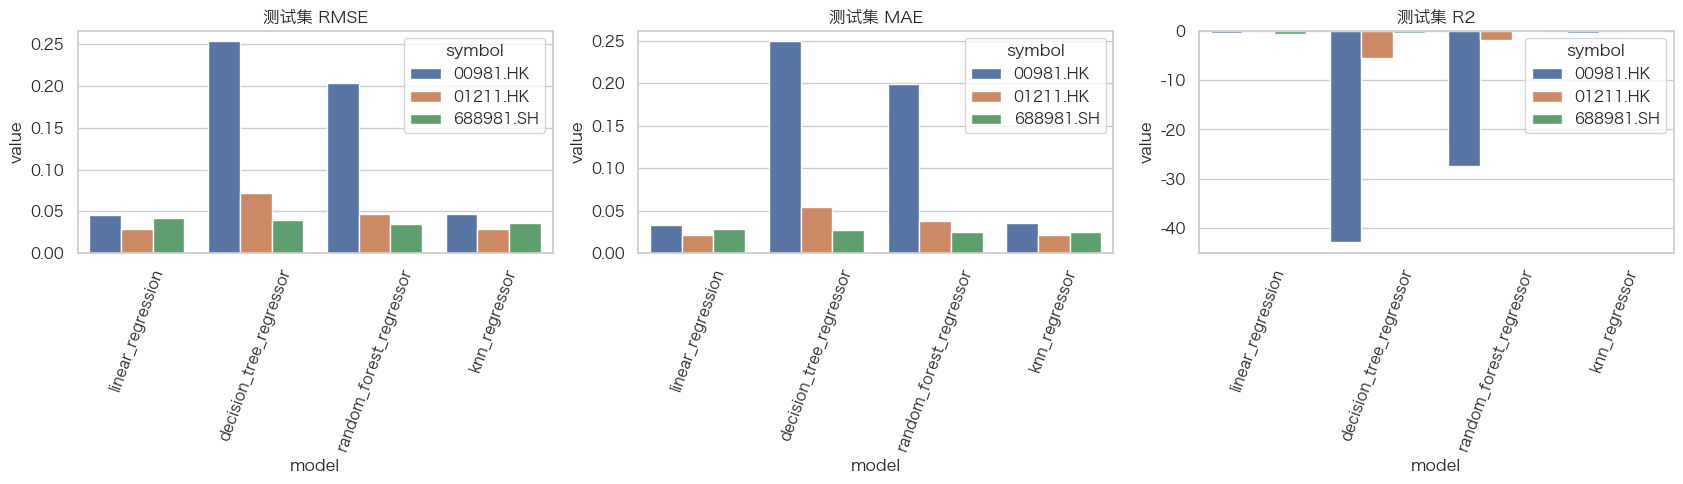

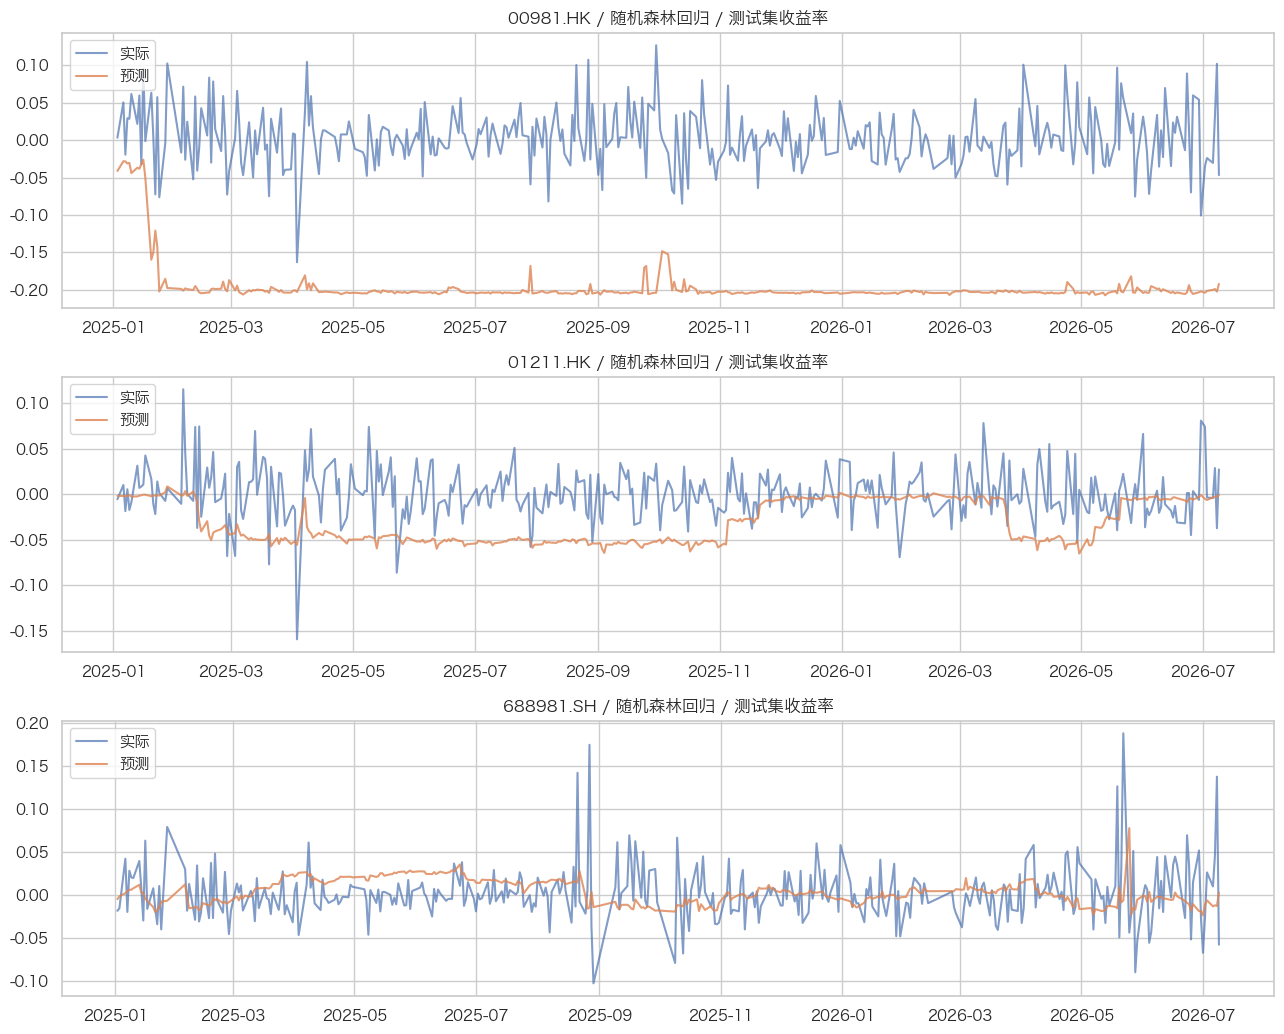

In [9]:
reg=metrics_df[metrics_df.task_type=='regression']
if len(reg):
    display(reg.pivot_table(index=['dataset','symbol','model'],columns='metric',values='value').round(6))
    fig,axes=plt.subplots(1,3,figsize=(17,5))
    for ax,metric in zip(axes,['RMSE','MAE','R2']):
        sns.barplot(data=reg[(reg.dataset=='test')&(reg.metric==metric)],x='model',y='value',hue='symbol',ax=ax)
        ax.tick_params(axis='x',rotation=70); ax.set_title(f'测试集 {metric}')
    plt.tight_layout(); plt.show()
    sample=predictions_df[(predictions_df.task_type=='regression')&(predictions_df.dataset=='test')&
                          (predictions_df.model=='random_forest_regressor')]
    if len(sample):
        symbols=sample.symbol.unique(); fig,axes=plt.subplots(len(symbols),1,figsize=(13,3.5*len(symbols)),sharex=False)
        for ax,symbol in zip(np.atleast_1d(axes),symbols):
            s=sample[sample.symbol==symbol]
            ax.plot(s.date,s.actual,label='实际',alpha=.7); ax.plot(s.date,s.prediction,label='预测',alpha=.8)
            ax.set_title(f'{symbol} / 随机森林回归 / 测试集收益率'); ax.legend()
        plt.tight_layout(); plt.show()

## 9. 分类指标、混淆矩阵与 ROC/AUC

metric                                            AUC  Accuracy      F1  \
dataset    symbol    model                                                
test       00981.HK  decision_tree_classifier  0.5089    0.4809  0.2520   
                     knn_classifier            0.4736    0.4918  0.1842   
                     logistic_regression       0.5535    0.4781  0.0104   
                     random_forest_classifier  0.5035    0.5109  0.1596   
           01211.HK  decision_tree_classifier  0.4786    0.4891  0.3661   
                     knn_classifier            0.5193    0.5601  0.4059   
                     logistic_regression       0.4181    0.5000  0.2343   
                     random_forest_classifier  0.5022    0.5355  0.1237   
           688981.SH decision_tree_classifier  0.5192    0.5194  0.5014   
                     knn_classifier            0.4994    0.4833  0.5529   
                     logistic_regression       0.5570    0.5444  0.4969   
                     random_forest_classifier  0.5590    0.5417  0.3726   
validation 00981.HK  decision_tree_classifier  0.5181    0.5288  0.5571   
                     knn_classifier            0.5552    0.5350  0.4670   
                     logistic_regression       0.5293    0.5391  0.2774   
                     random_forest_classifier  0.5143    0.5041  0.4248   
           01211.HK  decision_tree_classifier  0.4694    0.4816  0.5341   
                     knn_classifier            0.4711    0.4836  0.2800   
                     logistic_regression       0.5082    0.4918  0.0462   
                     random_forest_classifier  0.5313    0.4877  0.1438   
           688981.SH decision_tree_classifier  0.5788    0.5579  0.5244   
                     knn_classifier            0.5341    0.5062  0.4605   
                     logistic_regression       0.5183    0.5124  0.4070   
                     random_forest_classifier  0.5175    0.5145  0.4573   

metric                                         Precision  Recall  
dataset    symbol    model                                        
test       00981.HK  decision_tree_classifier     0.5161  0.1667  
                     knn_classifier               0.5833  0.1094  
                     logistic_regression          1.0000  0.0052  
                     random_forest_classifier     0.8095  0.0885  
           01211.HK  decision_tree_classifier     0.4355  0.3158  
                     knn_classifier               0.5500  0.3216  
                     logistic_regression          0.4118  0.1637  
                     random_forest_classifier     0.5217  0.0702  
           688981.SH decision_tree_classifier     0.5088  0.4943  
                     knn_classifier               0.4792  0.6534  
                     logistic_regression          0.5400  0.4602  
                     random_forest_classifier     0.5632  0.2784  
validation 00981.HK  decision_tree_classifier     0.4915  0.6429  
                     knn_classifier               0.4950  0.4420  
                     logistic_regression          0.5000  0.1920  
                     random_forest_classifier     0.4564  0.3973  
           01211.HK  decision_tree_classifier     0.4882  0.5894  
                     knn_classifier               0.4712  0.1992  
                     logistic_regression          0.4286  0.0244  
                     random_forest_classifier     0.4565  0.0854  
           688981.SH decision_tree_classifier     0.5728  0.4836  
                     knn_classifier               0.5126  0.4180  
                     logistic_regression          0.5260  0.3320  
                     random_forest_classifier     0.5238  0.4057

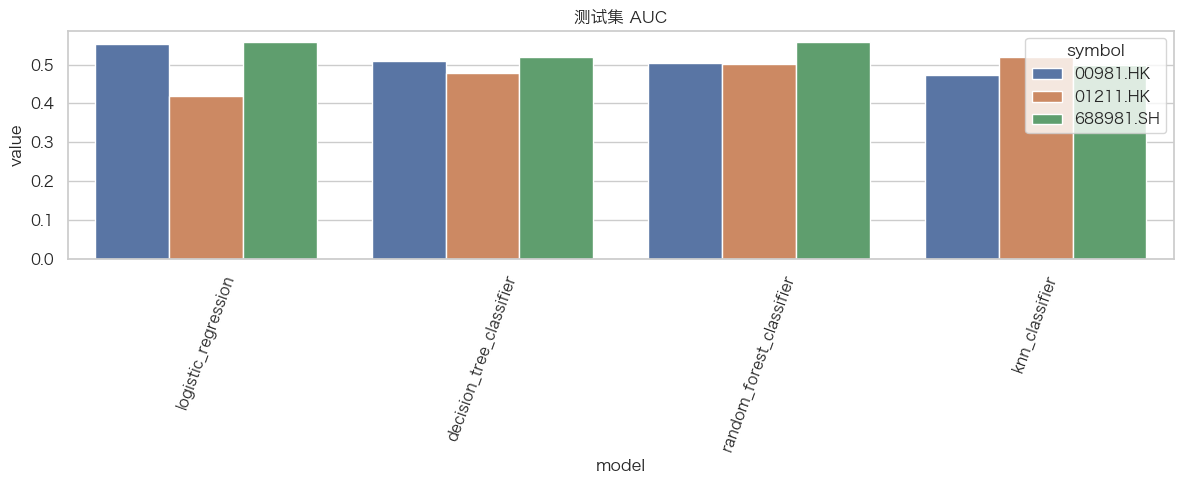

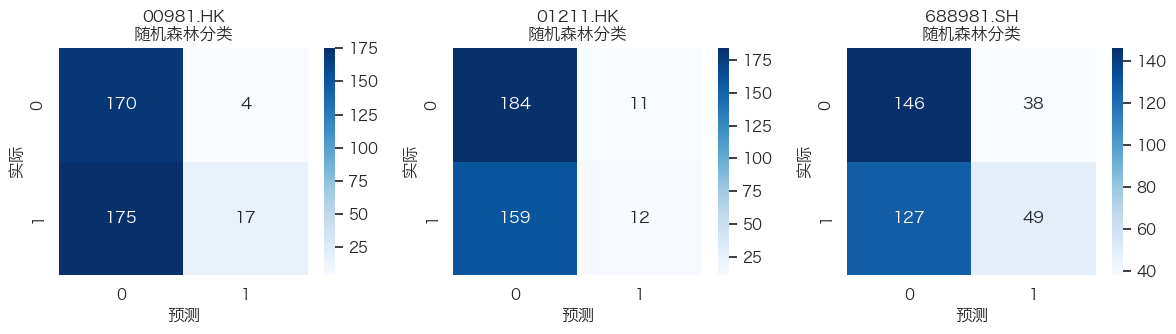

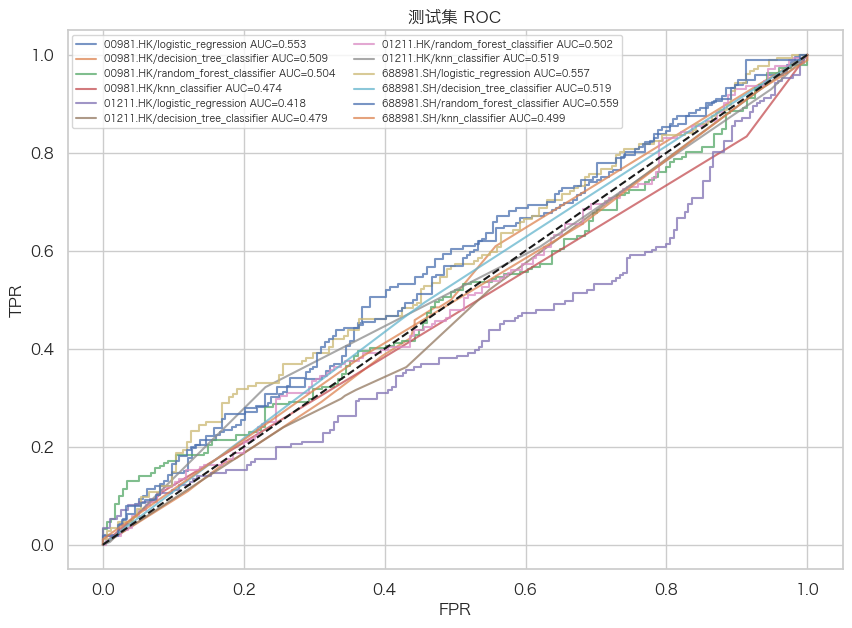

In [10]:
cls=metrics_df[metrics_df.task_type=='classification']
if len(cls):
    display(cls.pivot_table(index=['dataset','symbol','model'],columns='metric',values='value').round(4))
    test_auc=cls[(cls.dataset=='test')&(cls.metric=='AUC')]
    plt.figure(figsize=(12,5)); sns.barplot(data=test_auc,x='model',y='value',hue='symbol'); plt.xticks(rotation=70); plt.title('测试集 AUC'); plt.tight_layout(); plt.show()
    selected_cm=[x for x in cm_records if x[1]=='random_forest_classifier']
    n=len(selected_cm); fig,axes=plt.subplots(1,n,figsize=(4*n,3.5)); axes=np.atleast_1d(axes)
    for ax,(symbol,model_name,dataset,cm) in zip(axes,selected_cm):
        sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax); ax.set_title(f'{symbol}\n随机森林分类'); ax.set_xlabel('预测'); ax.set_ylabel('实际')
    plt.tight_layout(); plt.show()
    plt.figure(figsize=(10,7))
    for symbol,model_name,fpr,tpr,auc in roc_records:
        plt.plot(fpr,tpr,label=f'{symbol}/{model_name} AUC={auc:.3f}',alpha=.75)
    plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('测试集 ROC'); plt.legend(fontsize=7,ncol=2); plt.show()

## 10. 模型解释

In [11]:
importance_rows=[]
for (symbol,name),pipe in fitted_models.items():
    estimator=pipe.named_steps['model']
    values=getattr(estimator,'feature_importances_',None)
    if values is None and hasattr(estimator,'coef_'):
        values=np.ravel(estimator.coef_)
    if values is not None:
        for feature,value in zip(FEATURES,values): importance_rows.append({'symbol':symbol,'model':name,'feature':feature,'importance':value})
importance_df=pd.DataFrame(importance_rows)
if len(importance_df):
    display(importance_df.assign(abs_importance=lambda x:x.importance.abs()).sort_values('abs_importance',ascending=False).head(30))

,symbol,model,feature,importance,abs_importance
340,688981.SH,logistic_regression,sma_60,0.829059,0.829059
343,688981.SH,logistic_regression,volatility_20,0.811293,0.811293
334,688981.SH,logistic_regression,sma_5,-0.673093,0.673093
346,688981.SH,logistic_regression,macd,0.533337,0.533337
333,688981.SH,logistic_regression,return_20,-0.500840,0.500840
205,01211.HK,logistic_regression,close_to_sma_10,0.498866,0.498866
72,00981.HK,logistic_regression,sma_10,-0.439978,0.439978
341,688981.SH,logistic_regression,close_to_sma_60,0.425627,0.425627
339,688981.SH,logistic_regression,close_to_sma_20,0.353625,0.353625
203,01211.HK,logistic_regression,close_to_sma_5,-0.327215,0.327215


## 11. 保存可复现结果

In [12]:
out=PROJECT_ROOT/CONFIG['output']['directory']; figdir=out/'figures'; out.mkdir(parents=True,exist_ok=True); figdir.mkdir(exist_ok=True)
metrics_df.to_csv(out/'metrics_all.csv',index=False,encoding='utf-8-sig')
metrics_df[metrics_df.dataset=='validation'].to_csv(out/'metrics_validation.csv',index=False,encoding='utf-8-sig')
metrics_df[metrics_df.dataset=='test'].to_csv(out/'metrics_test.csv',index=False,encoding='utf-8-sig')
predictions_df.to_csv(out/'predictions_all.csv',index=False,encoding='utf-8-sig')
split_summary.to_csv(out/'split_summary.csv',index=False,encoding='utf-8-sig')
(out/'run_config.json').write_text(json.dumps(CONFIG,ensure_ascii=False,indent=2),encoding='utf-8')
print('结果目录:',out.resolve())

结果目录: /Users/binghuicheng/Downloads/myProjects/BA Workshop/task5_machine_learning/outputs


## 12. 如何换成自己的股票数据

只修改 `config.yaml` 的 `data.source`、`selected_symbols`、`task_type` 和 `selected_models` 即可。

标准 CSV 示例：`date,symbol,open,high,low,close,volume`。

非标准字段可设置：

```yaml
column_mapping:
  date: 日期
  symbol: 股票代码
  open: 开盘价
  high: 最高价
  low: 最低价
  close: 收盘价
  volume: 成交量
```

只运行随机森林分类器：

```yaml
experiment:
  task_type: classification
  selected_models: [random_forest_classifier]
```

也可直接调用：`data = load_stock_data(your_dataframe, selected_symbols=['YOUR_SYMBOL'])`，随后复用 `engineer_one`、`split_by_time`、`make_pipeline` 和统一训练流程。

局限性：历史结果不保证未来表现；当前标签未扣除交易成本；不同市场的交易制度、停牌、货币和公司行动仍需结合具体数据解释。